# Face Anti-Spoofing — Mixed Attack Training (25% FGSM + 25% PGD)
Fine-tune using 50% clean + 25% FGSM + 25% PGD adversarial images simultaneously.

| Section | Content |
|---------|----------|
| 1 | Imports & shared setup |
| 2 | Mixed attack training |
| 3 | Final evaluation |

> **Pre-requisite:** `best_2_finetune.pth` must be saved in `MODELS_PATH`.  
> **Training data:** LCC_FASD training split from `/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD`.


## 1. Imports & Shared Setup

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
print("All imports successful.")


All imports successful.


In [33]:
BASE_PATH   = "/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD"
MODELS_PATH = "/kaggle/input/models/mariammouh/bestmodel/pytorch/default/1"

CONFIG = {
    "train_dir"   : os.path.join(BASE_PATH, "LCC_FASD_training"),
    "val_dir"     : os.path.join(BASE_PATH, "LCC_FASD_development"),
    "test_dir"    : os.path.join(BASE_PATH, "LCC_FASD_evaluation"),
    "img_size"    : 224,
    "batch_size"  : 32,
    "epochs"      : 20,
    "lr"          : 1e-4,
    "weight_decay": 1e-4,
    "num_classes" : 2,
    "patience"    : 5,
    "device"      : "cuda" if torch.cuda.is_available() else "cpu",
    "seed"        : 42,
}
torch.manual_seed(CONFIG["seed"])
print(f"Device : {CONFIG['device']}  |  GPUs : {torch.cuda.device_count()}")
print(f"Train  : {CONFIG['train_dir']}")
print(f"Val    : {CONFIG['val_dir']}")
print(f"Test   : {CONFIG['test_dir']}")


Device : cuda  |  GPUs : 2
Train  : /kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_training
Val    : /kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_development
Test   : /kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation


### 1.1 Dataset & Transforms

In [34]:
class FaceAntiSpoofDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.image_paths, self.labels = [], []
        self.transform = transform
        for label, folder in [(1, "real"), (0, "spoof")]:
            folder_path = os.path.join(data_dir, folder)
            for fname in os.listdir(folder_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(folder_path, fname))
                    self.labels.append(label)
        print(f"  {os.path.basename(data_dir):30s}  real={self.labels.count(1):5d}  spoof={self.labels.count(0):6d}")

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def get_sampler(labels):
    counts = np.bincount(labels)
    return WeightedRandomSampler([1.0/counts[l] for l in labels], len(labels))

def build_dataloaders():
    tr_d = FaceAntiSpoofDataset(CONFIG["train_dir"], train_transform)
    va_d = FaceAntiSpoofDataset(CONFIG["val_dir"],   val_transform)
    te_d = FaceAntiSpoofDataset(CONFIG["test_dir"],  val_transform)
    tr_l = DataLoader(tr_d, batch_size=CONFIG["batch_size"],
                      sampler=get_sampler(tr_d.labels), num_workers=2, pin_memory=True)
    va_l = DataLoader(va_d, batch_size=CONFIG["batch_size"],
                      shuffle=False, num_workers=2, pin_memory=True)
    te_l = DataLoader(te_d, batch_size=CONFIG["batch_size"],
                      shuffle=False, num_workers=2, pin_memory=True)
    return tr_l, va_l, te_l, tr_d

print("Dataset, transforms, sampler ready.")


Dataset, transforms, sampler ready.


### 1.2 Attack Functions

In [35]:
def fgsm_attack(model, images, labels, device, epsilon=8/255):
    model.eval()
    images = images.clone().detach().requires_grad_(True).to(device)
    labels = labels.clone().detach().to(device)
    loss   = nn.CrossEntropyLoss()(model(images), labels)
    model.zero_grad(); loss.backward()
    with torch.no_grad():
        images_adv = torch.clamp(images + epsilon * images.grad.sign(), 0, 1)
    return images_adv.detach()

def pgd_attack(model, images, labels, device,
               epsilon=8/255, alpha=2/255, num_steps=10):
    model.eval()
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    x_adv  = images.clone().detach()
    for _ in range(num_steps):
        x_adv = x_adv.requires_grad_(True)
        loss  = nn.CrossEntropyLoss()(model(x_adv), labels)
        model.zero_grad(); loss.backward()
        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()
            delta = torch.clamp(x_adv - images, -epsilon, epsilon)
            x_adv = torch.clamp(images + delta, 0, 1).detach()
    return x_adv

print("Attack functions (FGSM, PGD) ready.")


Attack functions (FGSM, PGD) ready.


### 1.3 Model Builder

In [36]:
def build_model_2_finetune():
    model = timm.create_model('swin_base_patch4_window7_224',
                               pretrained=False, num_classes=CONFIG["num_classes"])
    for p in model.parameters():           p.requires_grad = False
    for p in model.layers[2].parameters(): p.requires_grad = True
    for p in model.layers[3].parameters(): p.requires_grad = True
    for p in model.norm.parameters():      p.requires_grad = True
    for p in model.head.parameters():      p.requires_grad = True
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n = sum(p.numel() for p in model.parameters())
    print(f"  2-Fine-tune | Trainable: {t:,} / {n:,}")
    return model

def load_best_model():
    m = build_model_2_finetune().to(CONFIG["device"])
    path = f"{MODELS_PATH}/best_2_finetune.pth"
    m.load_state_dict(torch.load(path, map_location=CONFIG["device"]))
    m.eval()
    print(f"  Loaded: {path}")
    return m

print("Model builder ready.")


Model builder ready.


### 1.4 Training & Evaluation Helpers

In [37]:
def train_one_epoch_adv(model, loader, optimizer, criterion, device, adv_fn, adv_kwargs):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs = adv_fn(model, imgs, labels, device, **adv_kwargs)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
        all_preds.extend(out.detach().argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), accuracy_score(all_labels, all_preds)

def evaluate(model, loader, criterion, device, split="Val"):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"  {split}", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score (all_labels, all_preds)
    f1  = f1_score       (all_labels, all_preds, zero_division=0)
    prec= precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score   (all_labels, all_preds, zero_division=0)
    return total_loss/len(loader), acc, prec, rec, f1, all_labels, all_preds

def plot_curves(history, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Training Curves — {title}", fontsize=14, fontweight="bold")
    for ax, metric, ylabel in zip(axes, ["loss","acc"], ["Loss","Accuracy"]):
        ax.plot(history[f"train_{metric}"], label="Train", marker="o", markersize=3)
        ax.plot(history[f"val_{metric}"],   label="Val",   marker="s", markersize=3)
        ax.set_title(ylabel); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

def plot_cm(true_labels, pred_labels, title, save_path, cmap="Blues"):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(true_labels, pred_labels),
        display_labels=["Spoof","Real"]
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def run_adv_training(model, save_path, strategy_name, adv_train_fn, adv_kwargs,
                     tr_l, va_l, te_l, tr_ds):
    """Generic adversarial training loop."""    
    counts    = np.bincount(tr_ds.labels)
    w         = torch.tensor(1.0/counts, dtype=torch.float).to(CONFIG["device"])
    criterion = nn.CrossEntropyLoss(weight=w)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

    history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}
    best_f1, no_improve = 0, 0

    for epoch in range(CONFIG["epochs"]):
        print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
        tr_loss, tr_acc = adv_train_fn(model, tr_l, optimizer, criterion,
                                        CONFIG["device"], **adv_kwargs)
        va_loss, va_acc, _, _, va_f1, _, _ = evaluate(model, va_l, criterion,
                                                       CONFIG["device"], "Val")
        scheduler.step()
        print(f"  Train → Loss:{tr_loss:.4f}  Acc:{tr_acc*100:.2f}%")
        print(f"  Val   → Loss:{va_loss:.4f}  Acc:{va_acc*100:.2f}%  F1:{va_f1*100:.2f}%")
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
        if va_f1 > best_f1:
            best_f1, no_improve = va_f1, 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved (F1={best_f1*100:.2f}%)")
        else:
            no_improve += 1
            if no_improve >= CONFIG["patience"]:
                print(f"  Early stopping at epoch {epoch+1}"); break

    safe = strategy_name.lower().replace(" ","_").replace("%","").replace("/","_").replace("+","_")
    plot_curves(history, strategy_name, f"/kaggle/working/curves_{safe}.png")

    model.load_state_dict(torch.load(save_path, map_location=CONFIG["device"]))
    _, te_acc, te_prec, te_rec, te_f1, true_l, pred_l = evaluate(
        model, te_l, criterion, CONFIG["device"], "Test")
    print(f"\nFinal Test — Acc:{te_acc*100:.2f}%  Prec:{te_prec*100:.2f}%  Rec:{te_rec*100:.2f}%  F1:{te_f1*100:.2f}%")
    print(classification_report(true_l, pred_l, target_names=["spoof","real"], digits=4))
    plot_cm(true_l, pred_l, f"CM — {strategy_name}", f"/kaggle/working/cm_{safe}.png")
    return model

print("All helper functions ready.")


All helper functions ready.


## 2. Mixed Attack Training (25% FGSM + 25% PGD)

Each batch contains **50% clean + 25% FGSM + 25% PGD** images.  
Balanced defense against both attack types simultaneously.

| Portion | Type |
|---------|------|
| 50% | Clean images |
| 25% | FGSM attacked (ε=8/255) |
| 25% | PGD attacked (ε=8/255, α=2/255, 7 steps) |


In [38]:
def train_mixed_epoch(model, loader, optimizer, criterion, device,
                      epsilon=8/255, alpha=2/255, pgd_steps=7,
                      fgsm_ratio=0.25, pgd_ratio=0.25):
    """One epoch: 50% clean + 25% FGSM + 25% PGD."""  
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for imgs, labels in tqdm(loader, desc="  Mixed-Attack", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        n = len(imgs)
        n_fgsm = int(n * fgsm_ratio)
        n_pgd  = int(n * pgd_ratio)
        if n_fgsm > 0:
            imgs[:n_fgsm] = fgsm_attack(model, imgs[:n_fgsm], labels[:n_fgsm], device, epsilon)
        if n_pgd > 0:
            imgs[n_fgsm:n_fgsm+n_pgd] = pgd_attack(
                model, imgs[n_fgsm:n_fgsm+n_pgd], labels[n_fgsm:n_fgsm+n_pgd],
                device, epsilon, alpha, pgd_steps)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
        all_preds.extend(out.detach().argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), accuracy_score(all_labels, all_preds)

print("train_mixed_epoch() ready.")


train_mixed_epoch() ready.


  LCC_FASD_training               real= 1302  spoof=  7444
  LCC_FASD_development            real=  416  spoof=  2590
  LCC_FASD_evaluation             real=  323  spoof=  7312
  2-Fine-tune | Trainable: 84,626,530 / 86,745,274
  Loaded: /kaggle/input/models/mariammouh/bestmodel/pytorch/default/1/best_2_finetune.pth

Epoch 1/20


  Train → Loss:0.2994  Acc:72.56%
  Val   → Loss:0.0522  Acc:98.44%  F1:94.37%
  ✓ Saved (F1=94.37%)

Epoch 2/20


  Train → Loss:0.2173  Acc:75.50%
  Val   → Loss:0.1352  Acc:95.48%  F1:85.34%

Epoch 3/20


  Train → Loss:0.2197  Acc:74.88%
  Val   → Loss:0.4777  Acc:92.35%  F1:77.54%

Epoch 4/20


  Train → Loss:0.2236  Acc:74.27%
  Val   → Loss:0.0669  Acc:98.90%  F1:95.99%
  ✓ Saved (F1=95.99%)

Epoch 5/20


  Train → Loss:0.2220  Acc:74.31%
  Val   → Loss:0.0666  Acc:98.50%  F1:94.48%

Epoch 6/20


  Train → Loss:0.2255  Acc:74.21%
  Val   → Loss:0.2062  Acc:92.61%  F1:78.02%

Epoch 7/20


  Train → Loss:0.2215  Acc:74.61%
  Val   → Loss:0.1021  Acc:97.84%  F1:92.02%

Epoch 8/20


  Train → Loss:0.2156  Acc:75.20%
  Val   → Loss:0.1005  Acc:97.87%  F1:92.29%

Epoch 9/20


  Train → Loss:0.2151  Acc:75.09%
  Val   → Loss:0.1374  Acc:98.10%  F1:92.72%
  Early stopping at epoch 9


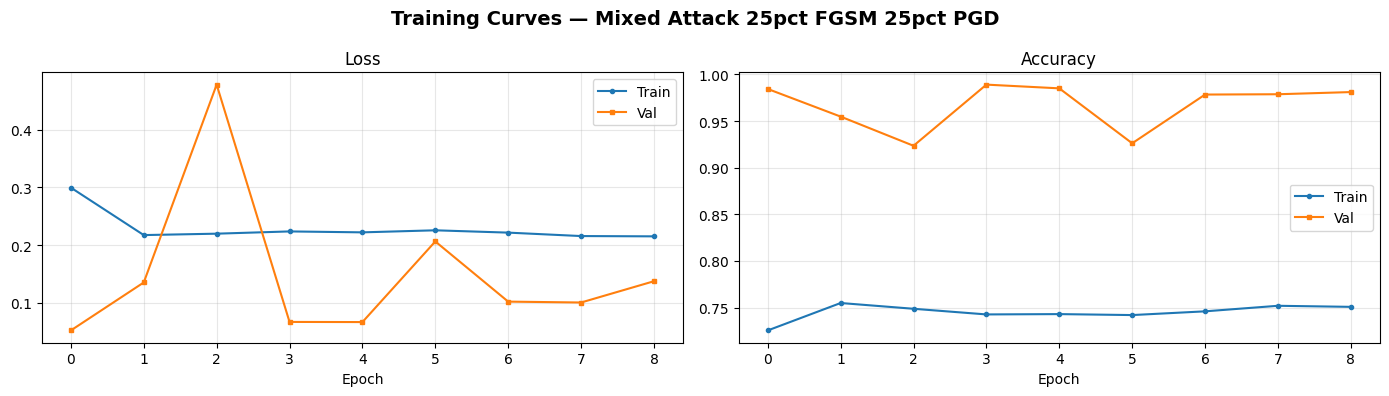

Saved: /kaggle/working/curves_mixed_attack_25pct_fgsm_25pct_pgd.png



Final Test — Acc:97.92%  Prec:70.60%  Rec:87.00%  F1:77.95%
              precision    recall  f1-score   support

       spoof     0.9942    0.9840    0.9891      7312
        real     0.7060    0.8700    0.7795       323

    accuracy                         0.9792      7635
   macro avg     0.8501    0.9270    0.8843      7635
weighted avg     0.9820    0.9792    0.9802      7635



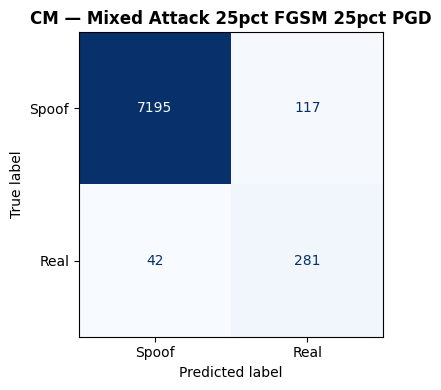


Saved: /kaggle/working/best_adv_mixed.pth


In [39]:
tr_l, va_l, te_l, tr_ds = build_dataloaders()
model_mixed = load_best_model()
model_mixed.train()

model_mixed = run_adv_training(
    model         = model_mixed,
    save_path     = "/kaggle/working/best_adv_mixed.pth",
    strategy_name = "Mixed Attack 25pct FGSM 25pct PGD",
    adv_train_fn  = train_mixed_epoch,
    adv_kwargs    = {"epsilon":8/255, "alpha":2/255, "pgd_steps":7,
                     "fgsm_ratio":0.25, "pgd_ratio":0.25},
    tr_l=tr_l, va_l=va_l, te_l=te_l, tr_ds=tr_ds,
)
print("\nSaved: /kaggle/working/best_adv_mixed.pth")


## 3. Final Evaluation — Clean + FGSM + PGD

[1/3] Clean ...


[2/3] FGSM ...


[3/3] PGD ...



  Mixed Attack Training — Final Results
Condition                     Acc    Prec     Rec      F1
------------------------------------------------------------
Clean                      97.92%  70.60%  87.00%  77.95%
FGSM (ε=8/255)              4.23%   4.23% 100.00%   8.12%
PGD (ε=8/255,s=10)          4.23%   4.23% 100.00%   8.12%


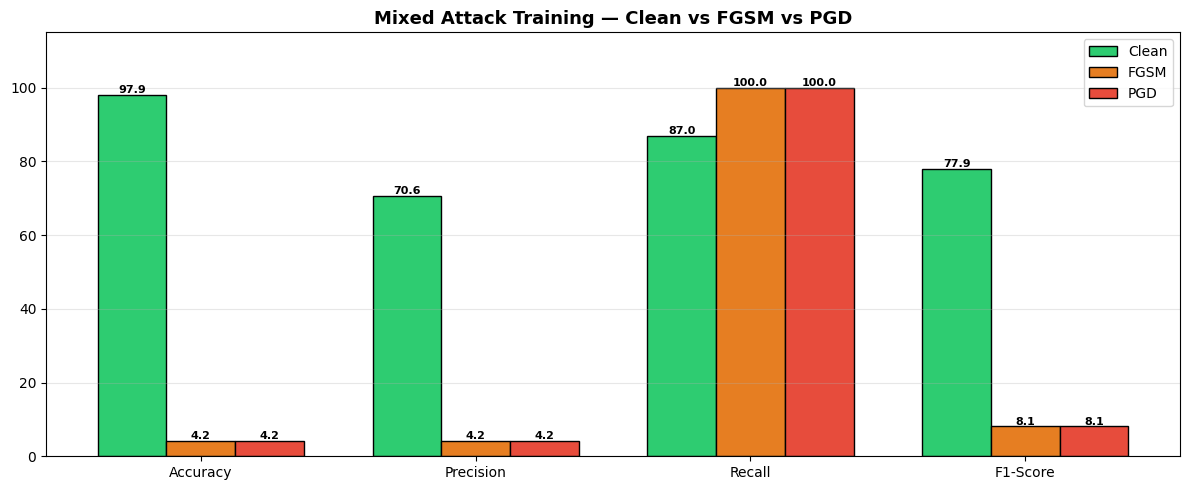

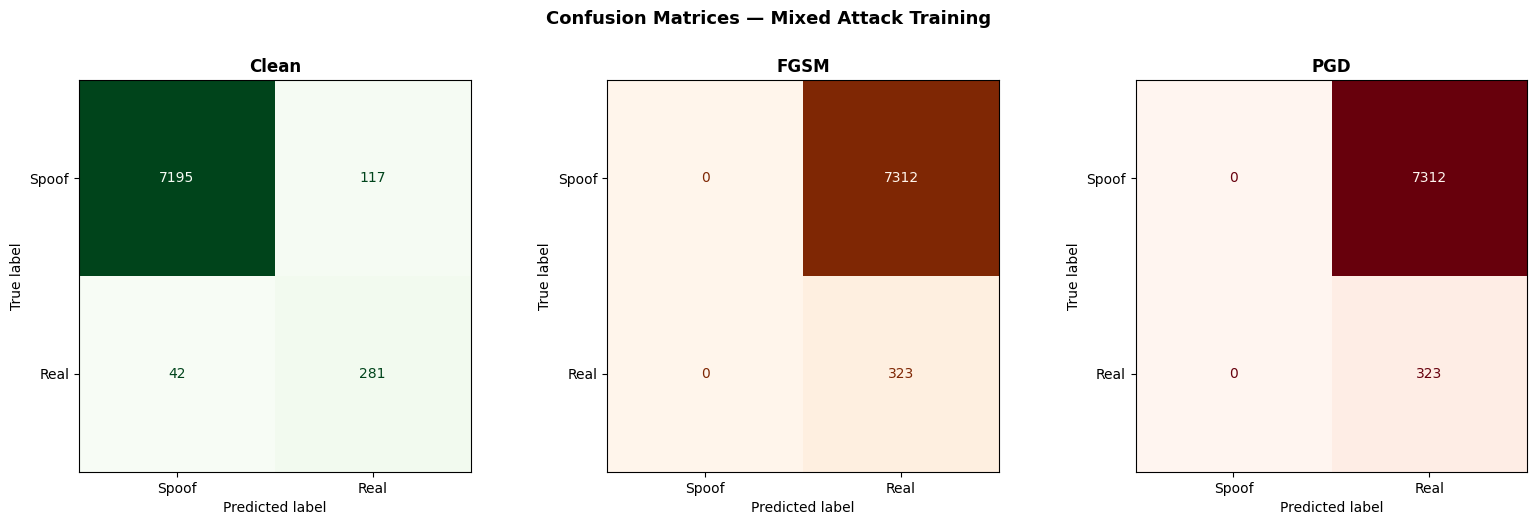

In [40]:
model_mixed.load_state_dict(torch.load("/kaggle/working/best_adv_mixed.pth",
                                       map_location=CONFIG["device"]))
model_mixed.eval()
criterion_eval = nn.CrossEntropyLoss()
EPSILON, ALPHA, STEPS = 8/255, 2/255, 10

print("[1/3] Clean ...")
_, acc_c, prec_c, rec_c, f1_c, true_c, pred_c = evaluate(
    model_mixed, te_l, criterion_eval, CONFIG["device"], "Clean")

print("[2/3] FGSM ...")
all_p_f, all_l_f = [], []
for imgs, labels in tqdm(te_l, desc="  FGSM", leave=False):
    imgs, labels = imgs.to(CONFIG["device"]), labels.to(CONFIG["device"])
    imgs_adv = fgsm_attack(model_mixed, imgs, labels, CONFIG["device"], EPSILON)
    with torch.no_grad():
        all_p_f.extend(model_mixed(imgs_adv).argmax(1).cpu().numpy())
    all_l_f.extend(labels.cpu().numpy())
acc_f=accuracy_score(all_l_f,all_p_f); prec_f=precision_score(all_l_f,all_p_f,zero_division=0)
rec_f=recall_score(all_l_f,all_p_f,zero_division=0); f1_f=f1_score(all_l_f,all_p_f,zero_division=0)

print("[3/3] PGD ...")
all_p_p, all_l_p = [], []
for imgs, labels in tqdm(te_l, desc="  PGD", leave=False):
    imgs, labels = imgs.to(CONFIG["device"]), labels.to(CONFIG["device"])
    imgs_adv = pgd_attack(model_mixed, imgs, labels, CONFIG["device"], EPSILON, ALPHA, STEPS)
    with torch.no_grad():
        all_p_p.extend(model_mixed(imgs_adv).argmax(1).cpu().numpy())
    all_l_p.extend(labels.cpu().numpy())
acc_p=accuracy_score(all_l_p,all_p_p); prec_p=precision_score(all_l_p,all_p_p,zero_division=0)
rec_p=recall_score(all_l_p,all_p_p,zero_division=0); f1_p=f1_score(all_l_p,all_p_p,zero_division=0)

print(f"\n{'='*60}\n  Mixed Attack Training — Final Results\n{'='*60}")
print(f"{'Condition':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}"); print("-"*60)
for name,a,p,r,f in [("Clean",acc_c,prec_c,rec_c,f1_c),
                      ("FGSM (ε=8/255)",acc_f,prec_f,rec_f,f1_f),
                      ("PGD (ε=8/255,s=10)",acc_p,prec_p,rec_p,f1_p)]:
    print(f"{name:<25} {a*100:>6.2f}% {p*100:>6.2f}% {r*100:>6.2f}% {f*100:>6.2f}%")
print("="*60)

categories = ["Accuracy","Precision","Recall","F1-Score"]
x, w = np.arange(4), 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i,(cond,vals,color) in enumerate(zip(
    ["Clean","FGSM","PGD"],
    [[acc_c,prec_c,rec_c,f1_c],[acc_f,prec_f,rec_f,f1_f],[acc_p,prec_p,rec_p,f1_p]],
    ["#2ecc71","#e67e22","#e74c3c"]
)):
    bars = ax.bar(x+(i-1)*w,[v*100 for v in vals],w,label=cond,color=color,edgecolor="black")
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.5,
                f"{b.get_height():.1f}",ha="center",fontsize=8,fontweight="bold")
ax.set_title("Mixed Attack Training — Clean vs FGSM vs PGD",fontsize=13,fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylim(0,115); ax.legend(); ax.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/eval_adv_mixed.png",dpi=150,bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1,3,figsize=(16,5))
for ax,(title,tl,pl),cmap in zip(axes,
    [("Clean",true_c,pred_c),("FGSM",all_l_f,all_p_f),("PGD",all_l_p,all_p_p)],
    ["Greens","Oranges","Reds"]):
    ConfusionMatrixDisplay(confusion_matrix(tl,pl),display_labels=["Spoof","Real"]).plot(ax=ax,colorbar=False,cmap=cmap)
    ax.set_title(title,fontweight="bold")
plt.suptitle("Confusion Matrices — Mixed Attack Training",fontsize=13,fontweight="bold",y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/cm_eval_adv_mixed.png",dpi=150,bbox_inches="tight"); plt.show()
